In [30]:
import numpy as np
import pandas as pd

In [31]:
df = pd.read_csv("../Voting_ensemble/Iris.csv")

In [32]:
df = df.iloc[:,1:]

In [33]:
from sklearn.preprocessing import LabelEncoder

In [34]:
encoder = LabelEncoder()

In [35]:
df["Species"] = encoder.fit_transform(df["Species"])

In [36]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

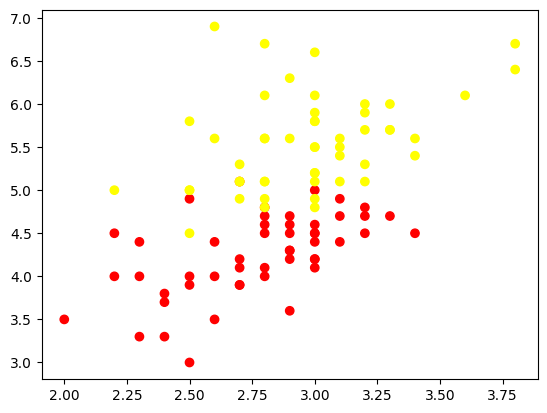

In [38]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='autumn')

In [39]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
103,2.9,5.6,2
93,2.3,3.3,1
85,3.4,4.5,1
99,2.8,4.1,1
97,2.9,4.3,1
88,3.0,4.1,1
83,2.7,5.1,1
82,2.7,3.9,1
89,2.5,4.0,1
55,2.8,4.5,1


In [40]:
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [41]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [ ]:
#Bag 1
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
88,3.0,4.1,1
97,2.9,4.3,1
103,2.9,5.6,2
93,2.3,3.3,1
83,2.7,5.1,1
85,3.4,4.5,1
89,2.5,4.0,1
88,3.0,4.1,1


In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [44]:
dt_bag1 = DecisionTreeClassifier()

In [45]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

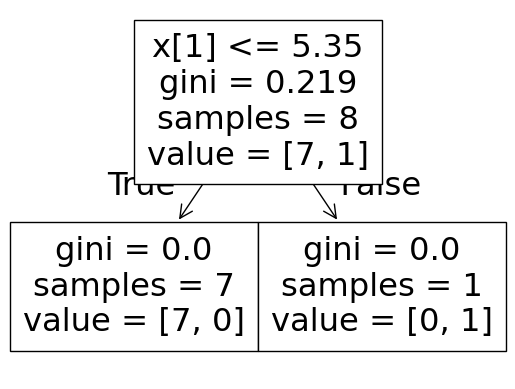

0.6


c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


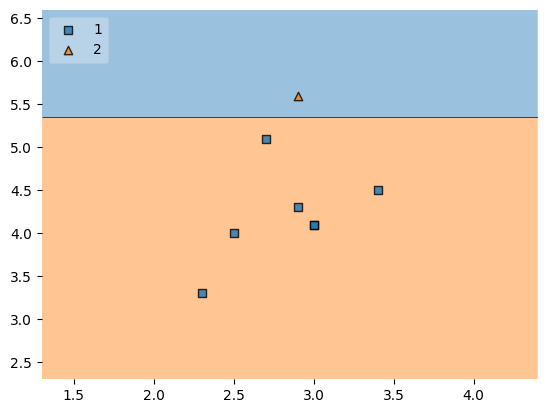

In [46]:
evaluate(dt_bag1,X,y)

In [47]:
#Bag 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag


,SepalWidthCm,PetalLengthCm,Species
88,3.0,4.1,1
82,2.7,3.9,1
89,2.5,4.0,1
93,2.3,3.3,1
88,3.0,4.1,1
55,2.8,4.5,1
103,2.9,5.6,2
103,2.9,5.6,2


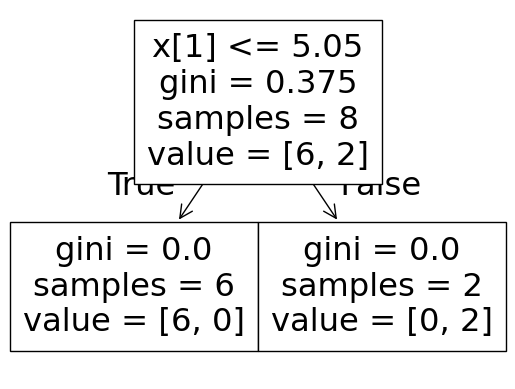

c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


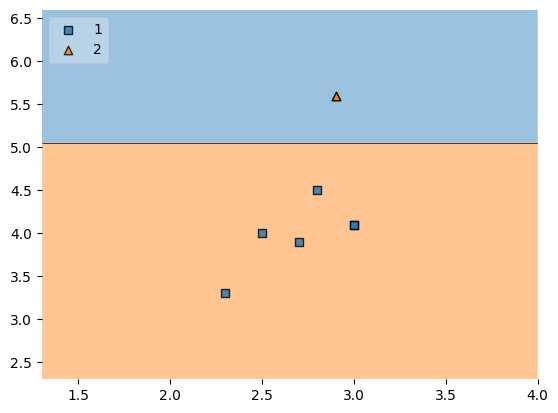

In [48]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [49]:
df_test

,SepalWidthCm,PetalLengthCm,Species
140,3.1,5.6,2
142,2.7,5.1,2
147,3.0,5.2,2
132,2.8,5.6,2
134,2.6,5.6,2


In [50]:
print("Predictor 1",dt_bag1.predict(np.array([3.1,5.6]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.1,5.6]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]


c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [52]:
dt_bag1.predict(X_test)

c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1, 2, 2, 1, 2])

In [53]:
dt_bag2.predict(X_test)

c:\Users\LENOVO\Desktop\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1, 2, 2, 1, 2])

In [54]:
y_test

array([2, 2, 2, 2, 2])

<h3>There are different types of bagging techniques

<h3>Basic Bagging</h3>
->This is the original method.
-> Random samples are taken with replacement (bootstrap samples).
-> Each model is trained independently
-> Final output = average (regression) or majority vote (classification)


<h3>Pasting</h3>
-> Like bagging, but sampling is without replacement
-> Each model gets a different subset of data


<h3>Random subspaces</h3>
Instead of sampling rows:
Use all rows
But randomly select features (columns) for each model
Example:
Model 1 uses features: age, income
Model 2 uses: age, education
Model 3 uses: income, education


<h3>Random Patches</h3>
 -> Combination of both:

Random rows (like bagging)
Random features (like random subspace)

